In [3]:
# Importer les bibliothèques necessaires
!pip install gdown
import gdown
import pandas as pd
import re
import gc
import os
import sys
import pandas as pd
import numpy as np
import tqdm
import seaborn as sns

import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split, StratifiedKFold, KFold
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from scipy.stats import chi2_contingency
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_score, recall_score, roc_curve, auc, classification_report, confusion_matrix, roc_auc_score
from sklearn.svm import SVC


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [4]:
np.random.seed(123)

In [5]:
# Charger les données
df = pd.read_csv("../Fraud Detection Dataset.csv")  # changer le nom du fichier si nécessaire
print('Forme du dataset chargé :', df.shape)
print(df['Fraudulent'].value_counts())


Forme du dataset chargé : (51000, 12)
Fraudulent
0    48490
1     2510
Name: count, dtype: int64


# **Sommaire**

### Traitement des valeurs manquantes Na
1. 1ère méthode : moyenne
2. 2ème méthode : Interpolation Bayesienne

### Implémentation des modèles de classification
1. *RandomForest*
2. *Régression Logistique*
3. *SVM*
4. *LightGBM*

### Algorithme de génération de données synthétiques : SMOTE

0. Implémentation SMOTE

### Résultats **sans SMOTE**
1. Mesures d'évaluation des modèles
2. Comparaison des courbes ROC et AUC 


### Résultats **avec SMOTE**
1. Mesures d'évaluation des modèles
2. Comparaison des courbes ROC et AUC 



## **Traitement des valeurs manquantes Na**


### **1ère méthode : moyenne**

Implémentation fonction *missing_mean*

In [6]:

def missing_mean(df):
    """
    entrée : dataset df avec valeurs manquantes Na 
    sortie :df_mean dataset traité 
    """

    # Séparation des colonnes numériques et catégorielles
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('Fraudulent')
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns

    # Création d'une copie de sécurité
    df_c = df.copy()
    
    # Remplacement des valeurs manquantes pour les variables numériques
    for col in numeric_cols:
        for fraud_value in [0, 1]:
            mean_value = df_c.loc[df_c['Fraudulent'] == fraud_value, col].mean()
            df_c.loc[(df_c['Fraudulent'] == fraud_value) & (df_c[col].isna()),col] = mean_value
    
    # Remplacement des valeurs manquantes pour les variables catégorielles
    for col in categorical_cols:
        for fraud_value in [0, 1]:
            mode_series = df_c.loc[df_c['Fraudulent'] == fraud_value, col].mode()
            if not mode_series.empty:
                mode_value = mode_series.iloc[0]
                df_c.loc[(df_c['Fraudulent'] == fraud_value) & (df_c[col].isna()),col] = mode_value
    
    # Vérification du remplissage
    print("Pourcentage de valeurs manquantes après traitement :")
    print((df_c.isnull().mean() * 100).round(3))

    return df_c


### **2ème méthode : Interpolation Bayesienne**

Implémentation fonction *missing_mean*

In [7]:

"""
Le code à rentrer ici prend en entrée "df" déjà définie juste avant et renvoie "df_interpolation"

"""

# 1) IMPUTATION BAYÉSIENNE POUR VARIABLES NUMÉRIQUES

def bayesian_impute_numeric(df, num_cols=None, alpha=1.0, random_state=None):

    if random_state is not None:
        np.random.seed(random_state)

    df_out = df.copy()

    # Sélection automatique des colonnes numériques si non spécifiée
    if num_cols is None:
        num_cols = df_out.select_dtypes(include=[np.number]).columns.tolist()

    # Imputation colonne par colonne
    for col in num_cols:
        if df_out[col].isna().sum() == 0:
            continue  # Rien à imputer

        print(f"\n--- Imputation bayésienne de la colonne numérique : {col} ---")

        # Séparation Observé / Manquant
        mask_obs = df_out[col].notna()
        mask_miss = df_out[col].isna()

        y_obs = df_out.loc[mask_obs, col].values

        X_obs = df_out.loc[mask_obs, num_cols].copy()
        X_miss = df_out.loc[mask_miss, num_cols].copy()

        # Remplacer éventuels NaN des prédicteurs par leur moyenne
        X_obs = X_obs.fillna(X_obs.mean())
        X_miss = X_miss.fillna(X_obs.mean())

        # Matrices numpy
        Xo = X_obs.values
        Xm = X_miss.values

        # Ridge posterior : beta_hat = (X'X + αI)^(-1) X'y
        XtX = Xo.T @ Xo
        XtY = Xo.T @ y_obs

        Sigma_beta = np.linalg.inv(XtX + alpha * np.eye(Xo.shape[1]))
        beta_hat = Sigma_beta @ XtY

        # Variance résiduelle
        residuals = y_obs - Xo @ beta_hat
        sigma2 = residuals.var()

        # Variance prédictive (approx)
        pred_var = sigma2 + np.sum(Xm @ Sigma_beta * Xm, axis=1)

        # Moyenne prédictive
        pred_mean = Xm @ beta_hat

        # Tirage Monte-Carlo
        y_draws = np.random.normal(pred_mean, np.sqrt(pred_var))

        # Injection des valeurs imputées
        df_out.loc[mask_miss, col] = y_draws

    return df_out

# 2) IMPUTATION BAYÉSIENNE POUR VARIABLES CATÉGORIELLES

def categorical_dirichlet_impute(df, cat_cols=None, alpha0=1.0, random_state=None):

    if random_state is not None:
        np.random.seed(random_state)

    df_out = df.copy()
    info = {}

    if cat_cols is None:
        cat_cols = df_out.select_dtypes(include=['object','category']).columns.tolist()

    for col in cat_cols:
        n_missing = df_out[col].isna().sum()
        if n_missing == 0:
            continue

        print(f"\n--- Imputation Dirichlet-Multinomial : {col} ---")

        observed = df_out[col].dropna().astype(str)
        counts = observed.value_counts().to_dict()

        categories = list(counts.keys())
        counts_arr = np.array(list(counts.values()), dtype=float)

        # Prior Dirichlet symétrique
        alpha = np.ones_like(counts_arr) * alpha0

        # Posterior = counts + prior
        posterior = counts_arr + alpha
        probs = posterior / posterior.sum()

        # Tirage pour chaque NA
        draws = np.random.choice(categories, size=n_missing, p=probs)

        # Injection
        missing_indices = df_out.index[df_out[col].isna()]
        df_out.loc[missing_indices, col] = draws

        info[col] = {
            "n_missing": n_missing,
            "categories": counts,
            "probs": dict(zip(categories, probs))
        }

    return df_out, info


def missing_interpolation(df):
    """
    entrée : dataset df avec valeurs manquantes Na
    sortie : dataset df_interpolation avec valeurs manquantes Na remplacées
    """
    # 1) Imputation numérique bayésienne
    df_num = bayesian_impute_numeric(df, alpha=1.0, random_state=123)

    # 2) Imputation catégorielle Dirichlet-Multinomial
    cat_cols = ["Device_Used", "Location", "Payment_Method"]

    df_traite, info = categorical_dirichlet_impute(df_num, cat_cols, alpha0=1.0, random_state=123)

    return df_traite


#df_final.to_csv("Fraud_Dataset_imputed_full.csv", index=False)



Preprocessing : 
Séparation des variables explicatives X de la variable expliquée y 

In [8]:
df_mean=missing_mean(df)
df_interpolation=missing_interpolation(df)

Pourcentage de valeurs manquantes après traitement :
Transaction_ID                      0.0
User_ID                             0.0
Transaction_Amount                  0.0
Transaction_Type                    0.0
Time_of_Transaction                 0.0
Device_Used                         0.0
Location                            0.0
Previous_Fraudulent_Transactions    0.0
Account_Age                         0.0
Number_of_Transactions_Last_24H     0.0
Payment_Method                      0.0
Fraudulent                          0.0
dtype: float64

--- Imputation bayésienne de la colonne numérique : Transaction_Amount ---

--- Imputation bayésienne de la colonne numérique : Time_of_Transaction ---

--- Imputation Dirichlet-Multinomial : Device_Used ---



--- Imputation Dirichlet-Multinomial : Location ---

--- Imputation Dirichlet-Multinomial : Payment_Method ---


/tmp/ipykernel_25312/984645087.py:18: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '3002.9993194473086' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_c.loc[(df_c['Fraudulent'] == fraud_value) & (df_c[col].isna()),col] = mean_value
/tmp/ipykernel_25312/984645087.py:18: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.9953598680140234' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_c.loc[(df_c['Fraudulent'] == fraud_value) & (df_c[col].isna()),col] = mean_value
/tmp/ipykernel_25312/984645087.py:18: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '59.98537842854197' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_c.

In [9]:
def separation(data):
    y=data['Fraudulent']
    X=data.drop(columns=['Fraudulent'])
    # Encodage des colonnes catégorielles
    for col in X.select_dtypes(include=['object','category']).columns:
        X[col] = LabelEncoder().fit_transform(X[col].astype(str))
    return X, y


### **Implémentation des modèles de classification**


### 1. *RandomForest*

In [10]:
def random_forest(A,b,T,t):
    """
    entrée :

    • (A,b) est le dataset d'entrainement 

    • (T,t) est le dataset de test

    sortie :

    • y_pred, y_pred_proba

    On suppose avoir déjà séparé le dataset en train et test
    """
    
    # entraînement du modèle
    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(A, b)
    
    #construction de y_pred
    y_pred=clf.predict(T)
    
    #Regardons la distribution de probabilité qu'une transaction soit frauduleuse 
    y_pred_proba = clf.predict_proba(T)
    
    #On trace un histogramme de ces probas
    #pd.Series(y_pred_proba[:,1]).hist()

    return y_pred, y_pred_proba



### 2. *Régression Logistique*

Implémentation fonction *logistic*

In [11]:
def logistic(A,b,T,t):
    """
    entrée :

    • (A,b) est le dataset d'entrainement 

    • (T,t) est le dataset de test

    sortie :

    • courbe ROC avec AUC
    • threshold intéressant et les métriques associées

    On suppose avoir déjà séparé le dataset en train et test
    """
    
    #import LogisticRegression et on fit au modèle
    from sklearn.linear_model import LogisticRegression
    lr = LogisticRegression()
    lr.fit(A,b)
    
    #construction de y_pred
    y_pred=lr.predict(T)
    
    
    #Regardons la distribution de probabilité qu'une transaction soit frauduleuse 
    y_pred_proba = lr.predict_proba(T)
    
    #On trace un histogramme de ces probas
    #pd.Series(y_pred_proba[:,1]).hist()

    return y_pred, y_pred_proba


    

### 3. *SVM*

In [12]:
def svm(A,b,T,t):
    """
    entrée :

    • (A,b) est le dataset d'entrainement 

    • (T,t) est le dataset de test

    sortie :

    • y_pred, y_pred_proba

    On suppose avoir déjà séparé le dataset en train et test
    """
    
    # entraînement du modèle
    svc =SVC(kernel = 'rbf', C= 5, gamma= 'scale', probability=True )
    svc.fit(A,b)

    
    #construction de y_pred
    y_pred=svc.predict(T)
    
    #Regardons la distribution de probabilité qu'une transaction soit frauduleuse 
    y_pred_proba = svc.predict_proba(T)
    
    #On trace un histogramme de ces probas
    #pd.Series(y_pred_proba[:,1]).hist()

    return y_pred, y_pred_proba



### 4. *LightGBM*

In [13]:
!pip install lightgbm
import lightgbm as lgb

def light_gbm(A,b,T,t):
    """
    entrée :

    • (A,b) est le dataset d'entrainement 

    • (T,t) est le dataset de test

    sortie :

    • y_pred, y_pred_proba

    On suppose avoir déjà séparé le dataset en train et test
    """
    
    # entraînement du modèle
    lgbm = lgb.LGBMClassifier(learning_rate=0.09,max_depth=-5,random_state=42)
    lgbm.fit(A, b)

    
    #construction de y_pred
    y_pred=lgbm.predict(T)
    
    #Regardons la distribution de probabilité qu'une transaction soit frauduleuse 
    y_pred_proba = lgbm.predict_proba(T)
    
    #On trace un histogramme de ces probas
    #pd.Series(y_pred_proba[:,1]).hist()

    return y_pred, y_pred_proba




[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


### **Algorithme de génération de données synthétiques : SMOTE**

0. Implémentation fonction *smote*

In [14]:
!pip install imblearn 

def smote(A,b,p):
    """
    (A,b) : dataset auquel est appliqué l'algorithme avec A les observations 
    des variables explicatives et b celles de la variable expliquée. 

    p : proportion de la classe minoritaire

    Remarques : On suppose ici que le dataset est traité, i.e que les valeurs manquantes
    ont été remplacées
    
    """
    P=A.reset_index(drop=True)
    q=b.reset_index(drop=True)


    try:
        #On exécute l'algorithme à partir du package imblearn
        from imblearn.over_sampling import SMOTE
        #On créer le modèle smote
        sm = SMOTE(sampling_strategy=p/(1-p), random_state=42) 
        #On applique smote au dataset (X,y) avec la méthode fit_resample
        X_res, y_res = sm.fit_resample(P, q) 
        #On vérifie que les classes ont bien été rééquilibrées
        print('Après SMOTE, comptes :', np.bincount(y_res.astype(int))) 


    #Si la première exécution a rencontré un problème
    except Exception as e:
        print('imblearn non disponible, SMOTE manuel.')
        # Version manuelle (comme avant)
        from sklearn.neighbors import NearestNeighbors
        X_np = P.values
        y_np = q.values
        minority_idx = np.where(y_np==1)[0]
        X_min = X_np[minority_idx]
        print(len(X_min))
        
        # SMOTE manuel
        n_majority = np.sum(y_np==0)
        target_ratio = p
        n_samples_needed = int(p*len(A) - len(X_min))
        print(n_samples_needed)
        
        
        neigh = NearestNeighbors(n_neighbors=5).fit(X_min)
        rng = np.random.RandomState(42)
        X_res,y_res=P,q
        for i in range(n_samples_needed):
            synthetic = []
            idx = rng.randint(0, X_min.shape[0])
            nn = neigh.kneighbors([X_min[idx]], return_distance=False)[0]
            nn_choice = rng.choice(nn[1:]) if len(nn) > 1 else nn[0]
            diff = X_min[nn_choice] - X_min[idx]
            gap = rng.rand()
            synthetic.append(X_min[idx] + gap * diff)
            #X_res = np.vstack([A, np.array(synthetic)])
            #y_res = np.hstack([b, np.ones(len(synthetic))])
            X_res=pd.concat([X_res, pd.DataFrame(synthetic,columns=P.columns)], axis = 0,ignore_index=True)
            y_res=pd.concat([y_res, pd.Series(1)], axis = 0, ignore_index=True)
        print('Après SMOTE manuel p, nouvelles formes :', X_res.shape, np.bincount(y_res.astype(int)))
    return X_res, y_res

def smote_bis(A,b,p):
    P=A.reset_index(drop=True)
    q=b.reset_index(drop=True)
    
    #On exécute l'algorithme à partir du package imblearn
    from imblearn.over_sampling import SMOTE
    #On créer le modèle smote
    sm = SMOTE(sampling_strategy=p/(1-p), random_state=42) 
    #On applique smote au dataset (X,y) avec la méthode fit_resample
    X_res, y_res = sm.fit_resample(P, q) 
    #On vérifie que les classes ont bien été rééquilibrées
    print('Après SMOTE, comptes :', np.bincount(y_res.astype(int)))
    return X_res, y_res





[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


### **Métriques d'évaluation des modèles et courbes ROC (et AUC)**

1. Implémentation fonction résultat métriques

In [15]:
def metrics(y_pred,y_pred_proba,T,t,synthese):
    """
    entrée :

    • y_pred : valeurs prédites de la variable y
    • y_pred_proba : distribution de probabilité d'appartenance au deux classes des observations 
    X_test

    • (T,t) est le dataset de test

    • synthese est un booléen pour retourner ou non les valeurs des métriques

    sortie :

    • threshold intéressant, métriques associées + matrice de confusion

    On suppose avoir déjà séparé le dataset en train et test
    """
    

    #Tracé de la courbe ROC
    import matplotlib.pyplot as plt
    from sklearn.metrics import roc_curve, auc, roc_auc_score

    """
    fpr : FP rate
    tpr : TP rate
    ths : threshold
    """  

    #La fonction roc_curve permet de tracer la courbe ROC 
    # à partir d'un vecteur de probabilités de la classe positive (ici (fraudulent=1))
    fpr, tpr, ths = roc_curve(t, y_pred_proba[:,1])
    auc_score = auc(fpr,tpr)
    #plt.plot(fpr,tpr,label="AUC Score:" + str(auc_score))
    #plt.xlabel('FALSE POSITIVE rate',fontsize='15')
    #plt.ylabel('TRUE POSITIVE rate',fontsize='15')
    #plt.legend(loc='best')





    #Recherche d'un seuil (threshold) idéal 
    """
    On souhaiterait maximiser le taux de détection d'une transaction frauduleuse
    tout en minimisant le taux de transaction non frauduleuses classées comme tel

    On va pour cela agir sur le seuil de classification (threshold)

    On va pour cela utiliser l'indice de Youden qui va nous permettre d'obtenir un 
    seuil de façon optimale selon l'indice de Youden. 
    """

    ###________ Au seuil optimal obtenu grâce à l'indice de Youden_________ ###
    """
    On va maximiser la quantité : recall + specificty - 1 
    On en tirera un seuil optimal noté threshold_y
    On s'intéressera aux métrques associées à ce seuil afin de les comparer à
    celles sans l'indice de Youden

    """
    youden= tpr - fpr
    index_max= np.where(youden==np.max(youden))
    threshold_index= np.max(index_max)
    threshold=ths[threshold_index]

    #On obtient de même de nouvelles valeurs prédites ajustées
    from sklearn.preprocessing import binarize
    from sklearn.metrics import confusion_matrix, f1_score
    y_pred_th= binarize(y_pred_proba, threshold=threshold)
    confusion_mat = confusion_matrix(t, y_pred_th[:,1],labels=[1,0])

    #Les métriques associées avec Youden
    recall=tpr[threshold_index]
    precision=(confusion_mat[0,0])/(confusion_mat[0,0] + confusion_mat[1,0])
    specificity=1-fpr[threshold_index]
    f_score=2*precision*recall/(precision+recall)


    ###________  Au seuil de 50% (par défaut)_________  ###

    #Mesure de l'accuracy du modèle au seuil de 50%
    from sklearn.metrics import accuracy_score
    accuracy=accuracy_score(t,y_pred)

    #Matrice de confusion au seuil de 50%
    confusion_matrix(t, y_pred,labels = [1,0])

    #Les métriques au seuil de 50%
    prec = precision_score(t, y_pred)
    rec = recall_score(t, y_pred)
    fscore = f1_score(t, y_pred)


    if synthese:
        return [recall,specificity,precision,f_score,youden[threshold_index],threshold]
    else:
        #Affichage métriques au seuil obtenu grâce à l'indice de Youden
        print("threshold avec Youden: " + str(threshold) )
        print("recall (sensitivity) avec Youden : " + str(recall) )
        print("precision avec Youden:" + str(precision))
        print("specificity avec Youden: " + str(specificity) )
        print("f1-score avec Youden : " + str(fscore))
        print("Indice de Youden: " + str(youden[threshold_index]))
        
        #Affichage métriques au seuil de 50%
        print("accuracy:" +str(accuracy))
        print("recall (sensitivity) au seuil de 50% : " + str(rec) )
        print("precision au seuil de 50%:" + str(prec))
        print("f1-score au seuil de 50% : " + str(f_score))





2. Implémentation fonction de tracé des courbes ROC

In [16]:
def roc(y_pred,y_pred_proba,T,t,synthese):
    """
    entrée :

    • y_pred : valeurs prédites de la variable y
    • y_pred_proba : distribution de probabilité d'appartenance au deux classes des observations 
    X_test

    • (T,t) est le dataset de test

    sortie :

    • threshold intéressant et les métriques associées

    On suppose avoir déjà séparé le dataset en train et test
    """

    #Tracé de la courbe ROC
    import matplotlib.pyplot as plt
    from sklearn.metrics import roc_curve, auc, roc_auc_score

    """
    fpr : FP rate
    tpr : TP rate
    ths : threshold
    """  

    #La fonction roc_curve permet de tracer la courbe ROC 
    # à partir d'un vecteur de probabilités de la classe positive (ici (fraudulent=1))
    fpr, tpr, ths = roc_curve(t, y_pred_proba[:,1])
    auc_score = auc(fpr,tpr)
   
    #Mesure de l'accuracy du modèle
    from sklearn.metrics import accuracy_score
    accuracy=accuracy_score(t,y_pred)

    if synthese:
        return [auc_score]
    else:
        #Affichage AUC
        print("accuracy:" +str(accuracy))
        print("AUC: "+ str(auc_score))
        print(classification_report(t, y_pred))
        
        # Tracé effectif de la courbe ROC
        plt.figure(figsize=(6,5))
        plt.plot(fpr, tpr)
        plt.plot([0,1],[0,1],'--')
        plt.xlabel('Taux de Faux Positifs')
        plt.ylabel('Taux de Vrais Positifs')
        plt.title('Courbe ROC (AUC = %.3f)' % auc_score)
        plt.show()



In [17]:
## Split train/test pour chaque type d'imputation des valeurs manquantes

#Moyenne
X,y=separation(df_mean)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
random_state=42, stratify=y)

#Interpolation Bayesienne
P,q=separation(df_interpolation)
P_train, P_test, q_train, q_test = train_test_split(P, q, test_size=0.2, 
random_state=42, stratify=q)


### **Résultats sans SMOTE**

1. **Mesures** d'évaluation des modèles *(precision, accuracy, recall, specificity, f1-score)*

RandomForest

threshold avec Youden: 0.09
recall (sensitivity) avec Youden : 0.3286852589641434
precision avec Youden:0.0953360768175583
specificity avec Youden: 0.8204784491647763
f1-score avec Youden : 0.14074074074074075
Indice de Youden: 0.14916370812891966
accuracy:0.9545098039215686
recall (sensitivity) au seuil de 50% : 0.07569721115537849
precision au seuil de 50%:1.0
f1-score au seuil de 50% : 0.14780182247025922
accuracy:0.9545098039215686
AUC: 0.6017273451050407
              precision    recall  f1-score   support

           0       0.95      1.00      0.98      9698
           1       1.00      0.08      0.14       502

    accuracy                           0.95     10200
   macro avg       0.98      0.54      0.56     10200
weighted avg       0.96      0.95      0.94     10200



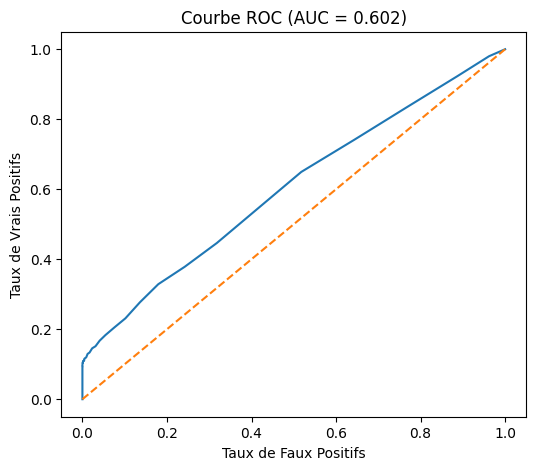

In [21]:
modele=random_forest
y_pred, y_pred_proba = modele(X_train, y_train, X_test, y_test)
metrics(y_pred, y_pred_proba,X_test, y_test,False)
roc(y_pred, y_pred_proba,X_test, y_test,False)

Régression Logistique

threshold avec Youden: 0.039331668139535876
recall (sensitivity) avec Youden : 0.6792828685258964
precision avec Youden:0.052011626128193364
specificity avec Youden: 0.3610022685089709
f1-score avec Youden : 0.0
Indice de Youden: 0.04028513703486725
accuracy:0.9507843137254902
recall (sensitivity) au seuil de 50% : 0.0
precision au seuil de 50%:0.0
f1-score au seuil de 50% : 0.09662483951767588
accuracy:0.9507843137254902
AUC: 0.5105001729522414
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      9698
           1       0.00      0.00      0.00       502

    accuracy                           0.95     10200
   macro avg       0.48      0.50      0.49     10200
weighted avg       0.90      0.95      0.93     10200



/opt/python/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/python/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/python/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWar

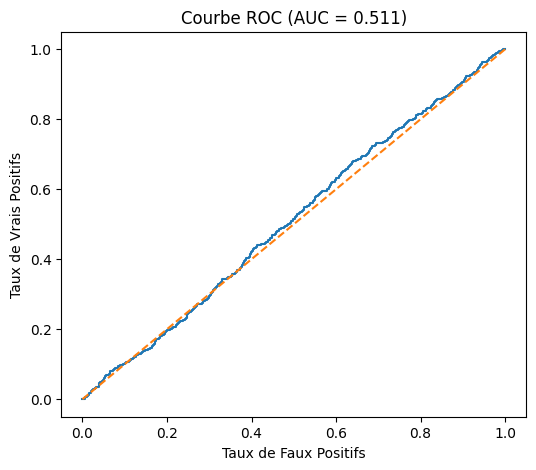

In [22]:
modele=logistic
y_pred, y_pred_proba = modele(X_train, y_train, X_test, y_test)
metrics(y_pred, y_pred_proba,X_test, y_test,False)
roc(y_pred, y_pred_proba,X_test, y_test,False)

SVM

threshold avec Youden: 0.05000053883048637
recall (sensitivity) avec Youden : 0.8904382470119522
precision avec Youden:0.050820419325433
specificity avec Youden: 0.14106001237368526
f1-score avec Youden : 0.0
Indice de Youden: 0.03149825938563744
accuracy:0.9507843137254902
recall (sensitivity) au seuil de 50% : 0.0
precision au seuil de 50%:0.0
f1-score au seuil de 50% : 0.09615304849757546
accuracy:0.9507843137254902
AUC: 0.49756161988466013
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      9698
           1       0.00      0.00      0.00       502

    accuracy                           0.95     10200
   macro avg       0.48      0.50      0.49     10200
weighted avg       0.90      0.95      0.93     10200



/opt/python/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/python/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/python/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/python/lib/python3.13/site-packages/s

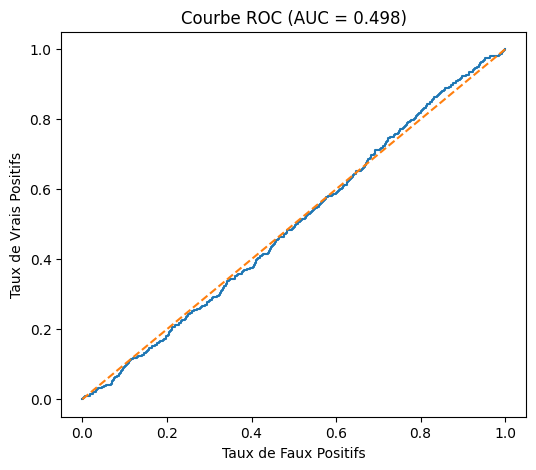

In [23]:
modele=svm
y_pred, y_pred_proba = modele(X_train, y_train, X_test, y_test)
metrics(y_pred, y_pred_proba,X_test, y_test,False)
roc(y_pred, y_pred_proba,X_test, y_test,False)

LightGBM

[LightGBM] [Info] Number of positive: 2008, number of negative: 38792
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000713 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 953
[LightGBM] [Info] Number of data points in the train set: 40800, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.049216 -> initscore=-2.961075
[LightGBM] [Info] Start training from score -2.961075
threshold avec Youden: 0.04247228367899819
recall (sensitivity) avec Youden : 0.599601593625498
precision avec Youden:0.06451612903225806
specificity avec Youden: 0.5514539080222727
f1-score avec Youden : 0.13553113553113552
Indice de Youden: 0.15105550164777065
accuracy:0.9537254901960784
recall (sensitivity) au seuil de 50% : 0.07370517928286853
precision au seuil de 50%:0.8409090909090909
f1-score au seuil de 50% : 0.11649733913884856
ac

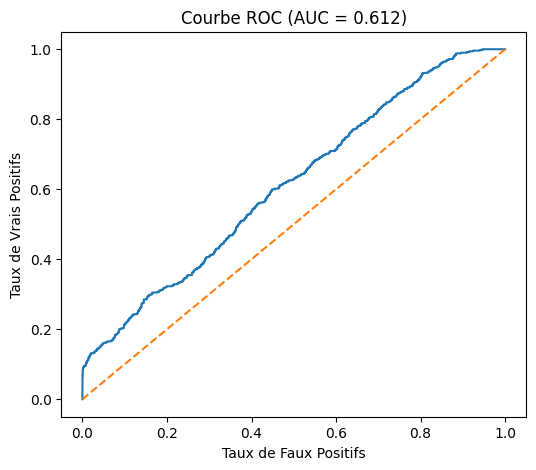

In [19]:
modele=light_gbm
y_pred, y_pred_proba = modele(X_train, y_train, X_test, y_test)
metrics(y_pred, y_pred_proba,X_test, y_test,False)
roc(y_pred, y_pred_proba,X_test, y_test,False)

### **Résultats avec SMOTE**

In [25]:
## Application SMOTE à la train
X_train_s, y_train_s=smote(X_train,y_train,0.2)
P_train_s,q_train_s=smote(P_train,q_train,0.2)

Après SMOTE, comptes : [38792  9698]
Après SMOTE, comptes : [38792  9698]


1. **Mesures** d'évaluation des modèles *(precision, accuracy, recall, specificity, f1-score)*

RandomForest

threshold avec Youden: 0.13
recall (sensitivity) avec Youden : 0.31673306772908366
precision avec Youden:0.05934455270150576
specificity avec Youden: 0.7440709424623634
f1-score avec Youden : 0.04642166344294004
Indice de Youden: 0.060804010191447044
accuracy:0.9516666666666667
recall (sensitivity) au seuil de 50% : 0.02390438247011952
precision au seuil de 50%:0.8
f1-score au seuil de 50% : 0.09996012104435949
accuracy:0.9516666666666667
AUC: 0.5342405383621217
              precision    recall  f1-score   support

           0       0.95      1.00      0.98      9698
           1       0.80      0.02      0.05       502

    accuracy                           0.95     10200
   macro avg       0.88      0.51      0.51     10200
weighted avg       0.94      0.95      0.93     10200



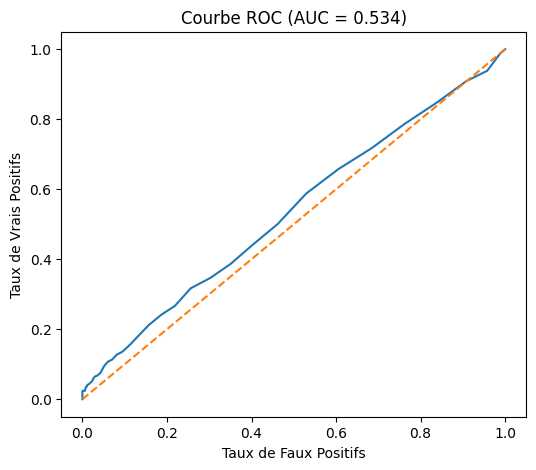

In [26]:
modele=random_forest
y_pred, y_pred_proba = modele(X_train_s, y_train_s, X_test, y_test)
metrics(y_pred, y_pred_proba,X_test, y_test,False)
roc(y_pred, y_pred_proba,X_test, y_test,False)

Régression Logistique

/opt/python/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/python/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/python/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWar

threshold avec Youden: 0.1686904068029289
recall (sensitivity) avec Youden : 0.7828685258964143
precision avec Youden:0.0519893899204244
specificity avec Youden: 0.26294081253866775
f1-score avec Youden : 0.0
Indice de Youden: 0.04580933843508206
accuracy:0.9507843137254902
recall (sensitivity) au seuil de 50% : 0.0
precision au seuil de 50%:0.0
f1-score au seuil de 50% : 0.0975036740459822
accuracy:0.9507843137254902
AUC: 0.5106164330099688
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      9698
           1       0.00      0.00      0.00       502

    accuracy                           0.95     10200
   macro avg       0.48      0.50      0.49     10200
weighted avg       0.90      0.95      0.93     10200



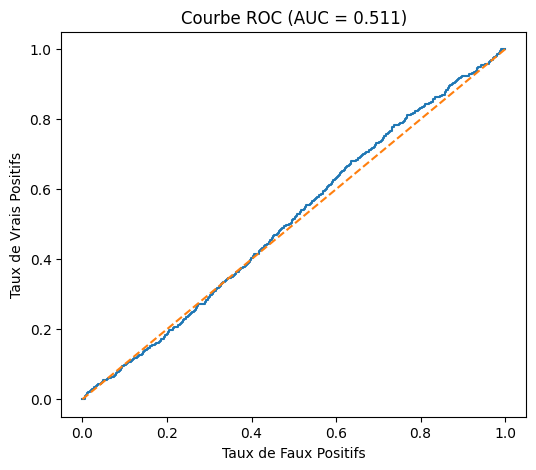

In [27]:
modele=logistic
y_pred, y_pred_proba = modele(X_train_s, y_train_s, X_test, y_test)
metrics(y_pred, y_pred_proba,X_test, y_test,False)
roc(y_pred, y_pred_proba,X_test, y_test,False)

SVM

threshold avec Youden: 0.20173790907748543
recall (sensitivity) avec Youden : 0.3784860557768924
precision avec Youden:0.05182341650671785
specificity avec Youden: 0.6434316353887399
f1-score avec Youden : 0.0
Indice de Youden: 0.021917691165632358
accuracy:0.9507843137254902
recall (sensitivity) au seuil de 50% : 0.0
precision au seuil de 50%:0.0
f1-score au seuil de 50% : 0.09116434461188513
accuracy:0.9507843137254902
AUC: 0.49996508090138925
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      9698
           1       0.00      0.00      0.00       502

    accuracy                           0.95     10200
   macro avg       0.48      0.50      0.49     10200
weighted avg       0.90      0.95      0.93     10200



/opt/python/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/python/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/python/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/python/lib/python3.13/site-packages/s

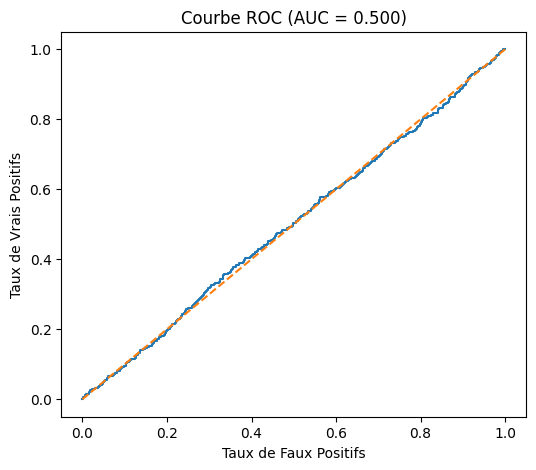

In [28]:
modele=svm
y_pred, y_pred_proba = modele(X_train_s, y_train_s, X_test, y_test)
metrics(y_pred, y_pred_proba,X_test, y_test,False)
roc(y_pred, y_pred_proba,X_test, y_test,False)

LightGBM

[LightGBM] [Info] Number of positive: 9698, number of negative: 38792
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000793 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1805
[LightGBM] [Info] Number of data points in the train set: 48490, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.200000 -> initscore=-1.386294
[LightGBM] [Info] Start training from score -1.386294
threshold avec Youden: 0.05885974503542991
recall (sensitivity) avec Youden : 0.5776892430278885
precision avec Youden:0.061476281642203784
specificity avec Youden: 0.5450608372860384
f1-score avec Youden : 0.12639405204460966
Indice de Youden: 0.12275008031392687
accuracy:0.953921568627451
recall (sensitivity) au seuil de 50% : 0.06772908366533864
precision au seuil de 50%:0.9444444444444444
f1-score au seuil de 50% : 0.11112672769509828


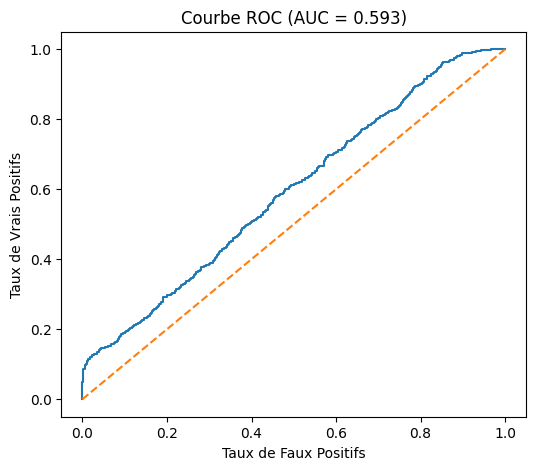

In [29]:
modele=light_gbm
y_pred, y_pred_proba = modele(X_train_s, y_train_s, X_test, y_test)
metrics(y_pred, y_pred_proba,X_test, y_test,False)
roc(y_pred, y_pred_proba,X_test, y_test,False)

### **Synthèse des résultats**

Création des dataset avec missing_mean et missing_interpolation

Résultats **Sans SMOTE**

In [30]:
no_smote_col = pd.MultiIndex.from_tuples([('Sans SMOTE','Moyenne', 'recall'),('Sans SMOTE','Moyenne', 'specificity'),
                                       ('Sans SMOTE','Moyenne', 'precision'),('Sans SMOTE','Moyenne', 'f1-score'),
                                       ('Sans SMOTE','Moyenne', 'Indice de Youden'),('Sans SMOTE','Moyenne', 'seuil optimal'),
                                       ('Sans SMOTE','Interpolation Bayésienne', 'recall'),('Sans SMOTE','Interpolation Bayésienne', 'specificity'),
                                       ('Sans SMOTE','Interpolation Bayésienne', 'precision'),('Sans SMOTE','Interpolation Bayésienne', 'f1-score'),
                                       ('Sans SMOTE','Interpolation Bayésienne', 'Indice de Youden'),('Sans SMOTE','Interpolation Bayésienne', 'seuil optimal')])



liste=[random_forest,logistic,svm,light_gbm]
M=[]
for modele in liste:
    y_pred, y_pred_proba = modele(X_train, y_train, X_test, y_test)
    q_pred, q_pred_proba = modele(P_train, q_train, P_test, q_test)
    L=metrics(y_pred, y_pred_proba,X_test, y_test,True) + metrics(q_pred, q_pred_proba,P_test, q_test,True)
    M.append(L)
df = pd.DataFrame(M,index=['RandomForest','Régression Logistique','SVM','LightGBM'],columns=no_smote_col)

/opt/python/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/python/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer 

[LightGBM] [Info] Number of positive: 2008, number of negative: 38792
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000636 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 953
[LightGBM] [Info] Number of data points in the train set: 40800, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.049216 -> initscore=-2.961075
[LightGBM] [Info] Start training from score -2.961075
[LightGBM] [Info] Number of positive: 2008, number of negative: 38792
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000748 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1182
[LightGBM] [Info] Number of data points in the train set: 40800, number of used features: 11
[LightGBM] [Info] [bi

In [31]:
df.stack(future_stack=True)

Sans SMOTE                         
                                          Moyenne Interpolation Bayésienne
RandomForest          recall             0.328685                 0.320717
                      specificity        0.820478                 0.737678
                      precision          0.095336                 0.060637
                      f1-score           0.147802                 0.101990
                      Indice de Youden   0.149164                 0.058395
                      seuil optimal      0.090000                 0.080000
Régression Logistique recall             0.679283                 0.776892
                      specificity        0.361002                 0.260260
                      precision          0.052012                 0.051435
                      f1-score           0.096625                 0.096482
                      Indice de Youden   0.040285                 0.037152
                      seuil optimal      0.039332                 0.032805
SVM                   recall             0.890438                 0.501992
                      specificity        0.141060                 0.530212
                      precision          0.050820                 0.052216
                      f1-score           0.096153                 0.094592
                      Indice de Youden   0.031498                 0.032204
                      seuil optimal      0.050866                 0.051126
LightGBM              recall             0.599602                 0.245020
                      specificity        0.551454                 0.805836
                      precision          0.064516                 0.060848
                      f1-score           0.116497                 0.097486
                      Indice de Youden   0.151056                 0.050856
                      seuil optimal      0.042472                 0.055310

Résultats **Avec SMOTE**


In [32]:
smote_col = pd.MultiIndex.from_tuples([('SMOTE','Moyenne', 'recall'),('SMOTE','Moyenne', 'specificity'),
                                       ('SMOTE','Moyenne', 'precision'),('SMOTE','Moyenne', 'f1-score'),
                                       ('SMOTE','Moyenne', 'Indice de Youden'),('SMOTE','Moyenne', 'seuil optimal'),
                                       ('SMOTE','Interpolation Bayésienne', 'recall'),('SMOTE','Interpolation Bayésienne', 'specificity'),
                                       ('SMOTE','Interpolation Bayésienne', 'precision'),('SMOTE','Interpolation Bayésienne', 'f1-score'),
                                       ('SMOTE','Interpolation Bayésienne', 'Indice de Youden'),('SMOTE','Interpolation Bayésienne', 'seuil optimal')])



liste=[random_forest,logistic,svm,light_gbm]
M=[]
for modele in liste:
    y_pred, y_pred_proba = modele(X_train_s, y_train_s, X_test, y_test)
    q_pred, q_pred_proba = modele(P_train_s, q_train_s, P_test, q_test)
    L=metrics(y_pred, y_pred_proba,X_test, y_test,True) + metrics(q_pred, q_pred_proba,P_test, q_test,True)
    M.append(L)
df = pd.DataFrame(M,index=['RandomForest','Régression Logistique','SVM','LightGBM'],columns=smote_col)

/opt/python/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/python/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer 

[LightGBM] [Info] Number of positive: 9698, number of negative: 38792
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000638 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1805
[LightGBM] [Info] Number of data points in the train set: 48490, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.200000 -> initscore=-1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Number of positive: 9698, number of negative: 38792
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000668 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1182
[LightGBM] [Info] Number of data points in the train set: 48490, number of used features: 11
[LightGBM] [Info] [b

In [33]:
df.stack(future_stack=True)

SMOTE                         
                                         Moyenne Interpolation Bayésienne
RandomForest          recall            0.316733                 0.314741
                      specificity       0.744071                 0.728191
                      precision         0.059345                 0.057232
                      f1-score          0.099960                 0.096853
                      Indice de Youden  0.060804                 0.042932
                      seuil optimal     0.130000                 0.180000
Régression Logistique recall            0.782869                 0.254980
                      specificity       0.262941                 0.778717
                      precision         0.051989                 0.055873
                      f1-score          0.097504                 0.091661
                      Indice de Youden  0.045809                 0.033697
                      seuil optimal     0.168690                 0.255319
SVM                   recall            0.378486                 0.772908
                      specificity       0.643432                 0.254898
                      precision         0.051823                 0.050834
                      f1-score          0.091164                 0.095394
                      Indice de Youden  0.021918                 0.027806
                      seuil optimal     0.200427                 0.199663
LightGBM              recall            0.577689                 0.117530
                      specificity       0.545061                 0.925345
                      precision         0.061476                 0.074169
                      f1-score          0.111127                 0.090945
                      Indice de Youden  0.122750                 0.042875
                      seuil optimal     0.058860                 0.118793

AUC **sans SMOTE**

In [34]:
no_smote_col = pd.MultiIndex.from_tuples([('Sans SMOTE','Moyenne', 'AUC'),('Sans SMOTE','Interpolation Bayésienne', 'AUC')])

liste=[random_forest,logistic,svm,light_gbm]
M=[]
for modele in liste:
    y_pred, y_pred_proba = modele(X_train, y_train, X_test, y_test)
    q_pred, q_pred_proba = modele(P_train, q_train, P_test, q_test)
    L=roc(y_pred, y_pred_proba,X_test, y_test,True) + roc(q_pred, q_pred_proba,P_test, q_test,True)
    M.append(L)
df = pd.DataFrame(M,index=['RandomForest','Régression Logistique','SVM','LightGBM'],columns=no_smote_col)

/opt/python/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/python/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer 

[LightGBM] [Info] Number of positive: 2008, number of negative: 38792
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000596 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 953
[LightGBM] [Info] Number of data points in the train set: 40800, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.049216 -> initscore=-2.961075
[LightGBM] [Info] Start training from score -2.961075
[LightGBM] [Info] Number of positive: 2008, number of negative: 38792
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000549 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1182
[LightGBM] [Info] Number of data points in the train set: 40800, number of used features: 11
[LightGBM] [Info] [bi

In [35]:
df.stack(future_stack=True)

Sans SMOTE                         
                             Moyenne Interpolation Bayésienne
RandomForest          AUC   0.601727                 0.527247
Régression Logistique AUC   0.510500                 0.505157
SVM                   AUC   0.502438                 0.508394
LightGBM              AUC   0.612198                 0.525040

AUC **avec SMOTE**

In [36]:
smote_col = pd.MultiIndex.from_tuples([('SMOTE','Moyenne', 'AUC'),('SMOTE','Interpolation Bayésienne', 'AUC')])

liste=[random_forest,logistic,svm,light_gbm]
M=[]
for modele in liste:
    y_pred, y_pred_proba = modele(X_train_s, y_train_s, X_test, y_test)
    q_pred, q_pred_proba = modele(P_train_s, q_train_s, P_test, q_test)
    L=roc(y_pred, y_pred_proba,X_test, y_test,True) + roc(q_pred, q_pred_proba,P_test, q_test,True)
    M.append(L)
df = pd.DataFrame(M,index=['RandomForest','Régression Logistique','SVM','LightGBM'],columns=smote_col)

/opt/python/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/python/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer 

[LightGBM] [Info] Number of positive: 9698, number of negative: 38792
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000782 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1805
[LightGBM] [Info] Number of data points in the train set: 48490, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.200000 -> initscore=-1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Number of positive: 9698, number of negative: 38792
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000706 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1182
[LightGBM] [Info] Number of data points in the train set: 48490, number of used features: 11
[LightGBM] [Info] [b

In [37]:
df.stack(future_stack=True)

SMOTE                         
                            Moyenne Interpolation Bayésienne
RandomForest          AUC  0.534241                 0.523233
Régression Logistique AUC  0.510616                 0.503783
SVM                   AUC  0.499965                 0.501703
LightGBM              AUC  0.592951                 0.508172

### **Conclusion sur le choix du modèle :**

Au vu de l'ensemble des performances, le modèle choisi est donc le lightGBM. 

Modifions les paramètres d'entrée du classificateur afin d'améliorer les performances du modèle. 

## **Fine-Tuning du modèle choisi : lightGBM**

Pour cela nous allons utiliser la fonction *RandomizedSearchCV* du package scikit-learn.

In [26]:
from sklearn.model_selection import RandomizedSearchCV

lgbm = lgb.LGBMClassifier(learning_rate=0.09,max_depth=-5,random_state=42)
param_dist={'learning rate':[0.01,0.05,0.1,0.2],'num_leaves':[31,50,100,200,300],
             'max_depth':[-1,10,15,20],'min_child_samples':[10,20,30,50],
             'subsample':[0.6,0.8,1],'colsample_bytree':[0.6,0.8,1],
             'reg_alpha':[0,0.1,1,5],'reg_lambda':[0,0.1,1,5],
             'n_estimators':[500,1000,2000]}

search=RandomizedSearchCV(lgbm,param_distributions=param_dist,n_iter=5,cv=5,scoring='roc_auc',
                          random_state=42,n_jobs=-1,verbose=2)

search.fit(X_train_s, y_train_s)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
[LightGBM] [Warning] Unknown parameter: rate
[LightGBM] [Warning] Unknown parameter: learning
[LightGBM] [Warning] Unknown parameter: rate
[LightGBM] [Warning] Unknown parameter: learning
[LightGBM] [Info] Number of positive: 7759, number of negative: 31033
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000522 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1805
[LightGBM] [Info] Number of data points in the train set: 38792, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.200015 -> initscore=-1.386198
[LightGBM] [Info] Start training from score -1.386198
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Unknown parameter: rate


Exception ignored on calling ctypes callback function <function _log_callback at 0x7fccad63a160>:
Traceback (most recent call last):
  File "/opt/python/lib/python3.13/site-packages/lightgbm/basic.py", line 287, in _log_callback
    def _log_callback(msg: bytes) -> None:
KeyboardInterrupt: 
Exception ignored on calling ctypes callback function <function _log_callback at 0x7f7879c92160>:
Traceback (most recent call last):
  File "/opt/python/lib/python3.13/site-packages/lightgbm/basic.py", line 287, in _log_callback
    def _log_callback(msg: bytes) -> None:
KeyboardInterrupt: 


No further splits with positive gain, best gain: -inf
No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

KeyboardInterrupt: 

In [39]:
print(search.best_params_)

{'subsample': 0.6, 'reg_lambda': 0, 'reg_alpha': 0.1, 'num_leaves': 100, 'n_estimators': 500, 'min_child_samples': 20, 'max_depth': 15, 'learning rate': 0.05, 'colsample_bytree': 1}


[LightGBM] [Info] Number of positive: 9698, number of negative: 38792
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000927 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1805
[LightGBM] [Info] Number of data points in the train set: 48490, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.200000 -> initscore=-1.386294
[LightGBM] [Info] Start training from score -1.386294
threshold avec Youden: 0.07626365442977283
recall (sensitivity) avec Youden : 0.20318725099601595
precision avec Youden:0.12998712998713
specificity avec Youden: 0.9302949061662198
f1-score avec Youden : 0.15328467153284672
Indice de Youden: 0.13348215716223577
accuracy:0.9545098039215686
recall (sensitivity) au seuil de 50% : 0.08366533864541832
precision au seuil de 50%:0.9130434782608695
f1-score au seuil de 50% : 0.1585459694050294
acc

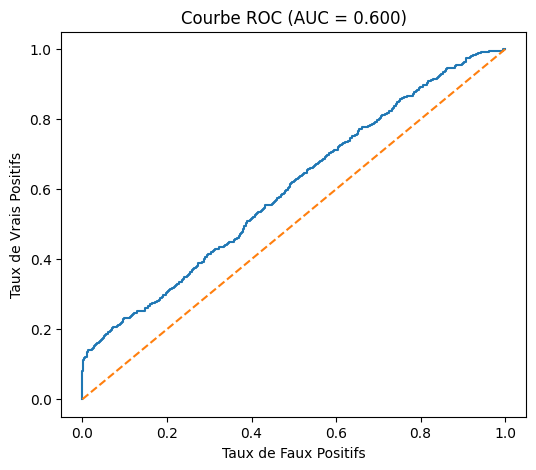

In [44]:
lg=lgb.LGBMClassifier(num_leaves=100,n_estimators=500,min_child_samples=20,max_depth=15,
                     learning_rate=0.05,colsample_bytree=1,subsample=0.6,reg_alpha=0.1,
                     reg_lambda=0)

lg.fit(X_train_s,y_train_s)

y_pred=lg.predict(X_test)
y_pred_proba=lg.predict_proba(X_test)
metrics(y_pred,y_pred_proba,X_test,y_test,False)
roc(y_pred,y_pred_proba,X_test,y_test,False)

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import lightgbm as lgb

# ─────────────────────────────────────────────
# Grilles d'hyperparamètres
# ─────────────────────────────────────────────

param_dist_rf = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [None, 10, 20, 30, 50],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf':  randint(1, 10),
    'max_features':      ['sqrt', 'log2'],
    'bootstrap':         [True],
}

param_dist_lgbm = {
    'n_estimators': [50, 100, 500, 2000],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [10, 20, 30, 40, 50],
    'max_depth': [-1, 3, 6, 9, 12],
    'min_child_samples': [10, 20, 30],
}

# Pour les pipelines avec SMOTE, les hyperparamètres
# doivent être préfixés du nom du step ('clf__')
param_dist_rf_smote = {f'clf__{k}': v for k, v in param_dist_rf.items()}
param_dist_lgbm_smote = {f'clf__{k}': v for k, v in param_dist_lgbm.items()}


# ─────────────────────────────────────────────
# Fonction générique de fine-tuning
# ─────────────────────────────────────────────

def fine_tune(estimator, param_dist, X_tr, y_tr, label):
    search = RandomizedSearchCV(
        estimator=estimator,
        param_distributions=param_dist,
        n_iter=50,
        cv=5,
        scoring='roc_auc',   # cohérent avec l'évaluation finale
        n_jobs=-1,
        verbose=1,
        random_state=42,
        return_train_score=True,
    )
    search.fit(X_tr, y_tr)
    print(f"\n[{label}] Meilleurs paramètres : {search.best_params_}")
    print(f"[{label}] Meilleur AUC CV       : {search.best_score_:.4f}")
    return search


# ─────────────────────────────────────────────
# 1. Random Forest — sans SMOTE
# ─────────────────────────────────────────────

rs_rf = fine_tune(
    estimator  = RandomForestClassifier(random_state=42),
    param_dist = param_dist_rf,
    X_tr       = X_train,
    y_tr       = y_train,
    label      = "RF sans SMOTE",
)

# ─────────────────────────────────────────────
# 2. Random Forest — avec SMOTE dans le pipeline
# ─────────────────────────────────────────────

pipeline_rf = Pipeline([
    ('smote', SMOTE(sampling_strategy=0.25, random_state=42)),
    ('clf',   RandomForestClassifier(random_state=42)),
])

rs_rf_smote = fine_tune(
    estimator  = pipeline_rf,
    param_dist = param_dist_rf_smote,
    X_tr       = X_train,   # ← données originales, SMOTE appliqué à l'intérieur du CV
    y_tr       = y_train,
    label      = "RF avec SMOTE",
)

# ─────────────────────────────────────────────
# 3. LightGBM — sans SMOTE
# ─────────────────────────────────────────────

rs_lgbm = fine_tune(
    estimator  = lgb.LGBMClassifier(random_state=42, verbose=-1),
    param_dist = param_dist_lgbm,
    X_tr       = X_train,
    y_tr       = y_train,
    label      = "LGBM sans SMOTE",
)

# ─────────────────────────────────────────────
# 4. LightGBM — avec SMOTE dans le pipeline
# ─────────────────────────────────────────────

pipeline_lgbm = Pipeline([
    ('smote', SMOTE(sampling_strategy=0.25, random_state=42)),
    ('clf',   lgb.LGBMClassifier(random_state=42, verbose=-1)),
])

rs_lgbm_smote = fine_tune(
    estimator  = pipeline_lgbm,
    param_dist = param_dist_lgbm_smote,
    X_tr       = X_train,
    y_tr       = y_train,
    label      = "LGBM avec SMOTE",
)

Fitting 5 folds for each of 50 candidates, totalling 250 fits

[RF sans SMOTE] Meilleurs paramètres : {'bootstrap': True, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 3, 'n_estimators': 500}
[RF sans SMOTE] Meilleur AUC CV       : 0.6339
Fitting 5 folds for each of 50 candidates, totalling 250 fits

[RF avec SMOTE] Meilleurs paramètres : {'clf__bootstrap': True, 'clf__max_depth': 50, 'clf__max_features': 'log2', 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 7, 'clf__n_estimators': 200}
[RF avec SMOTE] Meilleur AUC CV       : 0.5523
Fitting 5 folds for each of 50 candidates, totalling 250 fits

[LGBM sans SMOTE] Meilleurs paramètres : {'num_leaves': 10, 'n_estimators': 500, 'min_child_samples': 20, 'max_depth': -1, 'learning_rate': 0.01}
[LGBM sans SMOTE] Meilleur AUC CV       : 0.6495
Fitting 5 folds for each of 50 candidates, totalling 250 fits

[LGBM avec SMOTE] Meilleurs paramètres : {'clf__num_leaves': 10, 'clf__n_estimators': 500, 'c


  RF sans SMOTE
threshold avec Youden: 0.0453859769411474
recall (sensitivity) avec Youden : 0.6693227091633466
precision avec Youden:0.061648877438351124
specificity avec Youden: 0.4742214889667973
f1-score avec Youden : 0.06551059730250482
Indice de Youden: 0.14354419813014385
accuracy:0.9524509803921568
recall (sensitivity) au seuil de 50% : 0.03386454183266932
precision au seuil de 50%:1.0
f1-score au seuil de 50% : 0.11289903580452097
accuracy:0.9524509803921568
AUC: 0.6111670044918286
              precision    recall  f1-score   support

           0       0.95      1.00      0.98      9698
           1       1.00      0.03      0.07       502

    accuracy                           0.95     10200
   macro avg       0.98      0.52      0.52     10200
weighted avg       0.95      0.95      0.93     10200



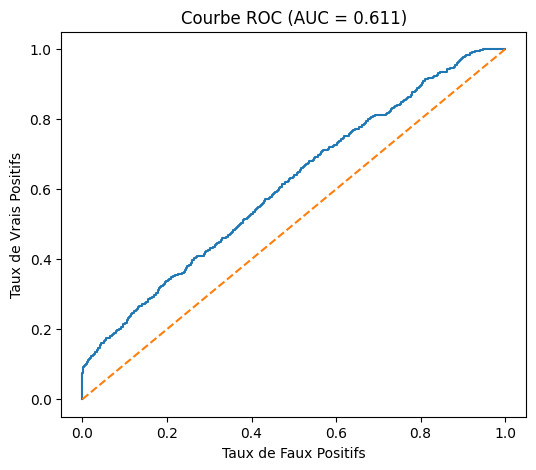


  RF avec SMOTE
threshold avec Youden: 0.1390674603174603
recall (sensitivity) avec Youden : 0.26693227091633465
precision avec Youden:0.06440677966101695
specificity avec Youden: 0.8007836667354093
f1-score avec Youden : 0.0
Indice de Youden: 0.067715937651744
accuracy:0.9506862745098039
recall (sensitivity) au seuil de 50% : 0.0
precision au seuil de 50%:0.0
f1-score au seuil de 50% : 0.1037743539577729
accuracy:0.9506862745098039
AUC: 0.5377528861662033
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      9698
           1       0.00      0.00      0.00       502

    accuracy                           0.95     10200
   macro avg       0.48      0.50      0.49     10200
weighted avg       0.90      0.95      0.93     10200



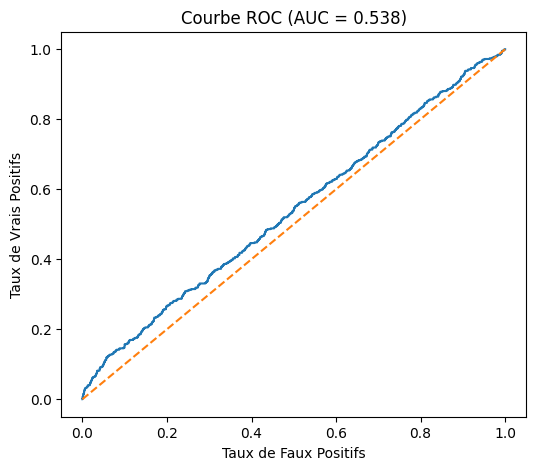


  LGBM sans SMOTE
threshold avec Youden: 0.04988715743274552
recall (sensitivity) avec Youden : 0.5119521912350598
precision avec Youden:0.07252124645892351
specificity avec Youden: 0.6624046195091772
f1-score avec Youden : 0.13284132841328414
Indice de Youden: 0.17435681074423692
accuracy:0.953921568627451
recall (sensitivity) au seuil de 50% : 0.07171314741035857
precision au seuil de 50%:0.9
f1-score au seuil de 50% : 0.127045674418425
accuracy:0.953921568627451
AUC: 0.626365850271835
              precision    recall  f1-score   support

           0       0.95      1.00      0.98      9698
           1       0.90      0.07      0.13       502

    accuracy                           0.95     10200
   macro avg       0.93      0.54      0.55     10200
weighted avg       0.95      0.95      0.93     10200



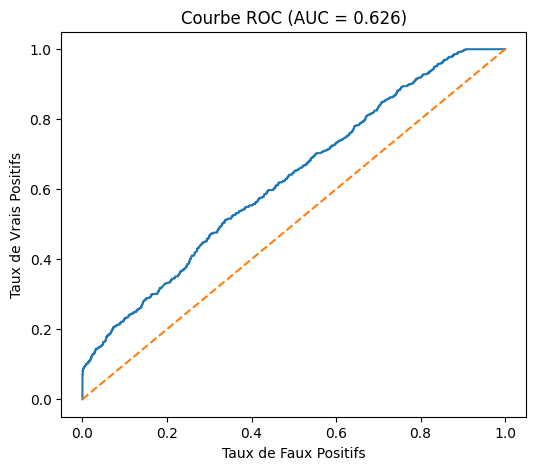


  LGBM avec SMOTE
threshold avec Youden: 0.04667185709417392
recall (sensitivity) avec Youden : 0.7529880478087649
precision avec Youden:0.05942622950819672
specificity avec Youden: 0.38471849865951746
f1-score avec Youden : 0.14652014652014653
Indice de Youden: 0.1377065464682824
accuracy:0.9543137254901961
recall (sensitivity) au seuil de 50% : 0.0796812749003984
precision au seuil de 50%:0.9090909090909091
f1-score au seuil de 50% : 0.11015867592527458
accuracy:0.9543137254901961
AUC: 0.6074791368656125
              precision    recall  f1-score   support

           0       0.95      1.00      0.98      9698
           1       0.91      0.08      0.15       502

    accuracy                           0.95     10200
   macro avg       0.93      0.54      0.56     10200
weighted avg       0.95      0.95      0.94     10200



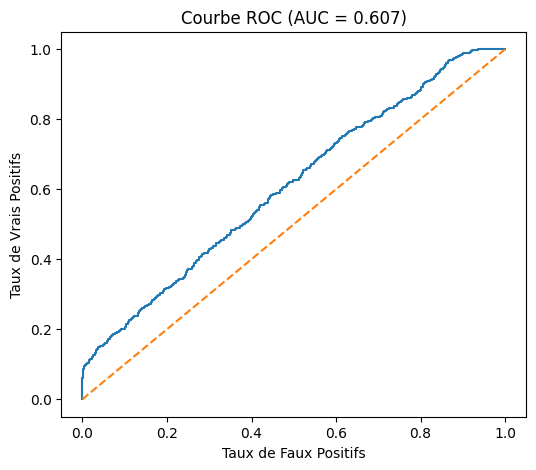

,AUC CV (validation)
RF sans SMOTE,0.6339
RF avec SMOTE,0.5523
LGBM sans SMOTE,0.6495
LGBM avec SMOTE,0.6281


In [20]:
# ─────────────────────────────────────────────
# Évaluation des 4 modèles sur X_test
# ─────────────────────────────────────────────

results_finetuning = {}

for label, search in [
    ("RF sans SMOTE",   rs_rf),
    ("RF avec SMOTE",   rs_rf_smote),
    ("LGBM sans SMOTE", rs_lgbm),
    ("LGBM avec SMOTE", rs_lgbm_smote),
]:
    best = search.best_estimator_
    y_pred       = best.predict(X_test)
    y_pred_proba = best.predict_proba(X_test)

    print(f"\n{'='*45}")
    print(f"  {label}")
    print(f"{'='*45}")
    metrics(y_pred, y_pred_proba, X_test, y_test, False)
    roc(y_pred, y_pred_proba, X_test, y_test, False)

    results_finetuning[label] = search.best_score_

# Tableau comparatif
import pandas as pd
pd.DataFrame.from_dict(results_finetuning, orient='index',
                       columns=['AUC CV (validation)']).round(4)